# Direct Preference Optimization (DPO) with Qwen2.5-0.5B-Instruct

This notebook provides a clean, end-to-end DPO training pipeline using:

- **TRL `DPOTrainer`**
- **Qwen2.5-0.5B-Instruct**
- **LoRA / optional 4-bit QLoRA**
- A small inline preference dataset, a local JSON file, or UltraFeedback
- Train/evaluation split
- Correct CUDA, BF16, and FP16 handling
- Correct PEFT adapter loading for inference
- Before/after evaluation and generation

> **Important:** The four inline examples are useful for demonstrating the pipeline, but they are far too small for meaningful model alignment. Use a larger, carefully reviewed preference dataset for a real project.

## What was wrong or incomplete in the original code?

1. The inline list of four examples was displayed but never assigned to a dataset, so it was not used.
2. `bf16=torch.cuda.is_available()` is unsafe because not every CUDA GPU supports BF16.
3. `fp16=not torch.cuda.is_available()` incorrectly enables FP16 on CPU.
4. The entire 63K-row UltraFeedback dataset was trained for three epochs, which is heavy for a teaching notebook.
5. There was no evaluation split or pre/post-training evaluation.
6. A LoRA checkpoint should be loaded as a PEFT model for reliable inference.
7. The inference cell decoded the prompt together with the generated answer instead of decoding only newly generated tokens.
8. `bitsandbytes` was installed but the original model was not actually loaded in 4-bit.

## 1. Install dependencies

In [1]:
%pip install -q -U transformers datasets trl peft accelerate bitsandbytes sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.2/863.2 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 15.9 MB/s eta 0:00:00


> After the installation cell finishes, restart the Colab runtime once if Colab asks you to do so. Then continue from the imports cell.

## 2. Imports and reproducibility

In [2]:
import gc
import json
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import transformers
import datasets
import trl
import peft

from datasets import Dataset, load_dataset
from peft import LoraConfig, AutoPeftModelForCausalLM
from transformers import AutoTokenizer, BitsAndBytesConfig, set_seed
from trl import DPOConfig, DPOTrainer

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("TRL:", trl.__version__)
print("PEFT:", peft.__version__)

PyTorch: 2.11.0+cu128
Transformers: 5.14.1
Datasets: 5.0.0
TRL: 1.8.0
PEFT: 0.19.1


## 3. Configuration

In [3]:
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
OUTPUT_DIR = "outputs/qwen2_5_0_5b_dpo_lora"

# Dataset options:
#   "inline"        -> uses the four examples included below
#   "json"          -> loads a local JSON file containing prompt/chosen/rejected
#   "ultrafeedback" -> loads a subset of trl-lib/ultrafeedback_binarized
DATA_SOURCE = "inline"

JSON_PATH = "preference_data.json"
ULTRAFEEDBACK_MAX_SAMPLES = 2_000

# 4-bit QLoRA is enabled automatically on a CUDA GPU.
USE_4BIT_IF_CUDA = True

MAX_LENGTH = 512
TRAIN_BATCH_SIZE = 1
EVAL_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 8
LEARNING_RATE = 5e-5
BETA = 0.1
INLINE_MAX_STEPS = 40

print("Model:", MODEL_NAME)
print("Dataset source:", DATA_SOURCE)
print("Output directory:", OUTPUT_DIR)

Model: Qwen/Qwen2.5-0.5B-Instruct
Dataset source: inline
Output directory: outputs/qwen2_5_0_5b_dpo_lora


## 4. Detect hardware and select numerical precision

In [4]:
HAS_CUDA = torch.cuda.is_available()
SUPPORTS_BF16 = HAS_CUDA and torch.cuda.is_bf16_supported()

USE_BF16 = SUPPORTS_BF16
USE_FP16 = HAS_CUDA and not SUPPORTS_BF16
USE_4BIT = HAS_CUDA and USE_4BIT_IF_CUDA

if USE_BF16:
    COMPUTE_DTYPE = torch.bfloat16
elif USE_FP16:
    COMPUTE_DTYPE = torch.float16
else:
    COMPUTE_DTYPE = torch.float32

if HAS_CUDA:
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: not available; CPU training will be slow.")

print("BF16:", USE_BF16)
print("FP16:", USE_FP16)
print("4-bit QLoRA:", USE_4BIT)
print("Compute dtype:", COMPUTE_DTYPE)

GPU: Tesla T4
BF16: True
FP16: False
4-bit QLoRA: True
Compute dtype: torch.bfloat16


## 5. Build or load the preference dataset

In [5]:
INLINE_DATA = [
    {
        "prompt": "Explain what machine learning is in simple words.",
        "chosen": "Machine learning is a way to teach computers to learn patterns from data and make predictions or decisions without being explicitly programmed for every case.",
        "rejected": "Machine learning is a machine that automatically learns everything without data.",
    },
    {
        "prompt": "What is overfitting in machine learning?",
        "chosen": "Overfitting happens when a model memorizes the training data too closely and performs poorly on new unseen data.",
        "rejected": "Overfitting means the model becomes perfect for all types of data.",
    },
    {
        "prompt": "What is the difference between classification and regression?",
        "chosen": "Classification predicts categories or labels, while regression predicts continuous numerical values.",
        "rejected": "Classification and regression are exactly the same thing.",
    },
    {
        "prompt": "What is the purpose of a loss function?",
        "chosen": "A loss function measures how far a model's predictions are from the true values, guiding the model during training.",
        "rejected": "A loss function increases model size and does not affect training.",
    },
]


def convert_plain_text_to_conversational(example):
    """Convert plain prompt/chosen/rejected strings into chat messages."""
    if isinstance(example.get("prompt"), str):
        return {
            "prompt": [{"role": "user", "content": example["prompt"]}],
            "chosen": [{"role": "assistant", "content": example["chosen"]}],
            "rejected": [{"role": "assistant", "content": example["rejected"]}],
        }
    return example


if DATA_SOURCE == "inline":
    dataset = Dataset.from_list(INLINE_DATA)
    dataset = dataset.map(convert_plain_text_to_conversational)

elif DATA_SOURCE == "json":
    json_path = Path(JSON_PATH)
    if not json_path.exists():
        raise FileNotFoundError(
            f"{JSON_PATH!r} was not found. Upload the file or change JSON_PATH."
        )

    dataset = load_dataset("json", data_files=str(json_path), split="train")
    required_columns = {"prompt", "chosen", "rejected"}
    missing = required_columns - set(dataset.column_names)
    if missing:
        raise ValueError(f"The JSON file is missing columns: {sorted(missing)}")

    dataset = dataset.map(convert_plain_text_to_conversational)

elif DATA_SOURCE == "ultrafeedback":
    dataset = load_dataset(
        "trl-lib/ultrafeedback_binarized",
        split="train",
    )
    dataset = dataset.shuffle(seed=SEED)
    sample_count = min(ULTRAFEEDBACK_MAX_SAMPLES, len(dataset))
    dataset = dataset.select(range(sample_count))

else:
    raise ValueError(
        "DATA_SOURCE must be 'inline', 'json', or 'ultrafeedback'."
    )

print(dataset)
print("\nColumns:", dataset.column_names)
print("\nFirst example:")
print(json.dumps(dataset[0], indent=2, ensure_ascii=False))

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 4
})

Columns: ['prompt', 'chosen', 'rejected']

First example:
{
  "prompt": [
    {
      "role": "user",
      "content": "Explain what machine learning is in simple words."
    }
  ],
  "chosen": [
    {
      "role": "assistant",
      "content": "Machine learning is a way to teach computers to learn patterns from data and make predictions or decisions without being explicitly programmed for every case."
    }
  ],
  "rejected": [
    {
      "role": "assistant",
      "content": "Machine learning is a machine that automatically learns everything without data."
    }
  ]
}


## 6. Validate and split the dataset

In [7]:
required_columns = {"chosen", "rejected"}
missing_columns = required_columns - set(dataset.column_names)

if missing_columns:
    raise ValueError(
        f"DPO requires chosen and rejected columns. Missing: {missing_columns}"
    )

if len(dataset) < 2:
    raise ValueError("At least two preference examples are required.")

test_size = 1 if len(dataset) < 20 else 0.05

split_dataset = dataset.train_test_split(
    test_size=test_size,
    seed=SEED,
)

train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

print("Training examples:", len(train_dataset))
print("Evaluation examples:", len(eval_dataset))

Training examples: 3
Evaluation examples: 1


## 7. Load and configure the tokenizer

In [8]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "left"

print("Pad token:", tokenizer.pad_token)
print("EOS token:", tokenizer.eos_token)
print("Padding side:", tokenizer.padding_side)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Pad token: <|endoftext|>
EOS token: <|im_end|>
Padding side: left


## 8. Configure optional 4-bit QLoRA

In [9]:
quantization_config = None

if USE_4BIT:
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=COMPUTE_DTYPE,
        bnb_4bit_use_double_quant=True,
    )

print("Quantization configuration:")
print(quantization_config)

Quantization configuration:
BitsAndBytesConfig {
  "_load_in_4bit": true,
  "_load_in_8bit": false,
  "bnb_4bit_compute_dtype": "bfloat16",
  "bnb_4bit_quant_storage": "uint8",
  "bnb_4bit_quant_type": "nf4",
  "bnb_4bit_use_double_quant": true,
  "llm_int8_enable_fp32_cpu_offload": false,
  "llm_int8_has_fp16_weight": false,
  "llm_int8_skip_modules": null,
  "llm_int8_threshold": 6.0,
  "load_in_4bit": true,
  "load_in_8bit": false,
  "quant_method": "bitsandbytes"
}



## 9. Configure LoRA

In [10]:
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules="all-linear",
)

print(peft_config)

LoraConfig(task_type='CAUSAL_LM', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.19.1', base_model_name_or_path=None, revision=None, inference_mode=False, r=16, target_modules='all-linear', exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, ensure_weight_tying=False)


## 10. Configure DPO training

In [11]:
model_init_kwargs = {
    "dtype": COMPUTE_DTYPE,
    "trust_remote_code": True,
    "attn_implementation": "sdpa",
}

is_tiny_inline_demo = DATA_SOURCE == "inline"

training_args = DPOConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=1.0,
    max_steps=INLINE_MAX_STEPS if is_tiny_inline_demo else -1,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    optim="paged_adamw_8bit" if USE_4BIT else "adamw_torch",
    max_grad_norm=1.0,
    beta=BETA,
    loss_type="sigmoid",
    max_length=MAX_LENGTH,
    truncation_mode="keep_start",
    bf16=USE_BF16,
    fp16=USE_FP16,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    use_cache=False,
    eval_strategy="steps",
    eval_steps=10,
    logging_steps=1,
    logging_first_step=True,
    save_strategy="steps",
    save_steps=20,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
    data_seed=SEED,
    model_init_kwargs=model_init_kwargs,
)

print(training_args)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


DPOConfig(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
activation_offloading=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
beta=0.1,
bf16=True,
bf16_full_eval=False,
data_seed=42,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
dataset_num_proc=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_dropout=True,
disable_tqdm=False,
discopop_tau=0.05,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_ba

## 11. Create the DPO trainer

`ref_model=None` is intentional. TRL uses the initial policy—the model state before DPO updates—as the reference policy. With PEFT, this avoids loading a separate full trainable copy.

In [12]:
trainer = DPOTrainer(
    model=MODEL_NAME,
    ref_model=None,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    peft_config=peft_config,
    quantization_config=quantization_config,
)

trainer.model.print_trainable_parameters()

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Tokenizing train dataset:   0%|          | 0/3 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1 [00:00<?, ? examples/s]

trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


## 12. Evaluate before training

In [13]:
initial_metrics = trainer.evaluate()
print("Initial evaluation metrics:")
for key, value in initial_metrics.items():
    print(f"{key}: {value}")

Training Loss,Validation Loss,Step,Entropy,Num Tokens,Logits/chosen,Logits/rejected,Mean Token Accuracy,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected
No log,0.693147,0,1.393978,0.000000,-2.202759,-0.573546,0.583333,0.000000,0.000000,0.000000,0.000000,-51.202583,-53.960358


Initial evaluation metrics:
eval_loss: 0.6931471824645996
eval_entropy: 1.3939778804779053
eval_num_tokens: 0.0
eval_logits/chosen: -2.2027589480082193
eval_logits/rejected: -0.5735460008893695
eval_mean_token_accuracy: 0.5833333134651184
eval_rewards/chosen: 0.0
eval_rewards/rejected: 0.0
eval_rewards/accuracies: 0.0
eval_rewards/margins: 0.0
eval_logps/chosen: -51.20258331298828
eval_logps/rejected: -53.960357666015625


## 13. Train the model

In [14]:
train_result = trainer.train()

print("Training completed.")
print("Global steps:", trainer.state.global_step)
print("Training loss:", train_result.training_loss)

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Logits/chosen,Logits/rejected,Mean Token Accuracy,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected
10,0.001758,0.349258,1.024148,3380.000000,-3.026045,-1.219167,0.583333,-0.162497,-1.034734,1.000000,0.872237,-52.827553,-64.307693
20,0.000034,0.198028,0.900396,6760.000000,-3.343337,-1.638533,0.541667,-0.665060,-2.183758,1.000000,1.518698,-57.853184,-75.797943
30,0.000018,0.213789,0.880276,10140.000000,-3.414648,-1.722823,0.541667,-0.850026,-2.283993,1.000000,1.433968,-59.702843,-76.800293
40,0.000018,0.182760,0.885462,13520.000000,-3.419253,-1.713988,0.541667,-0.728483,-2.335294,1.000000,1.606812,-58.487411,-77.313301


Training completed.
Global steps: 40
Training loss: 0.07717106491209051


## 14. Evaluate after training

In [15]:
final_metrics = trainer.evaluate()

print("Final evaluation metrics:")
for key, value in final_metrics.items():
    print(f"{key}: {value}")

Training Loss,Validation Loss,Step,Entropy,Num Tokens,Logits/chosen,Logits/rejected,Mean Token Accuracy,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected
0.000018,0.182760,40,0.885462,13520.000000,-3.419253,-1.713988,0.541667,-0.728483,-2.335294,1.000000,1.606812,-58.487411,-77.313301


Final evaluation metrics:
eval_loss: 0.18275976181030273
eval_entropy: 0.8854624032974243
eval_num_tokens: 13520.0
eval_logits/chosen: -3.4192527135213218
eval_logits/rejected: -1.7139877591814314
eval_mean_token_accuracy: 0.5416666865348816
eval_rewards/chosen: -0.7284828424453735
eval_rewards/rejected: -2.335294485092163
eval_rewards/accuracies: 1.0
eval_rewards/margins: 1.6068116426467896
eval_logps/chosen: -58.48741149902344
eval_logps/rejected: -77.31330108642578


## 15. Inspect the training log

,loss,grad_norm,learning_rate,entropy,num_tokens,logits/chosen,logits/rejected,mean_token_accuracy,rewards/chosen,rewards/rejected,...,eval_rewards/rejected,eval_rewards/accuracies,eval_rewards/margins,eval_logps/chosen,eval_logps/rejected,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
26,0.000022,0.001114,2.065880e-05,0.413200,8450.0,-3.598195,-3.583806,0.876587,3.162384,-7.857215,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,0.000021,0.001068,1.852952e-05,0.413284,8788.0,-3.609078,-3.590997,0.900397,3.156080,-7.912667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,0.000020,0.001007,1.644950e-05,0.401417,9126.0,-3.608424,-3.592254,0.876587,3.160409,-7.950314,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,0.000019,0.000965,1.443454e-05,0.401460,9464.0,-3.609897,-3.596299,0.900397,3.168843,-7.999446,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,0.000019,0.000931,1.250000e-05,0.402778,9802.0,-3.607100,-3.597114,0.900397,3.183345,-8.006614,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,0.000018,0.000916,1.066059e-05,0.399192,10140.0,-3.610153,-3.599542,0.900397,3.184234,-8.010313,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-2.283993,1.0,1.433968,-59.702843,-76.800293,NaN,NaN,NaN,NaN,NaN
33,0.000019,0.000961,8.930310e-06,0.402577,10478.0,-3.611563,-3.601729,0.900397,3.184252,-8.012849,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,0.000019,0.000957,7.322330e-06,0.405036,10816.0,-3.610498,-3.597572,0.888492,3.167512,-8.010346,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35,0.000018,0.000912,5.848889e-06,0.399434,11154.0,-3.608484,-3.608003,0.876587,3.178840,-8.042852,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


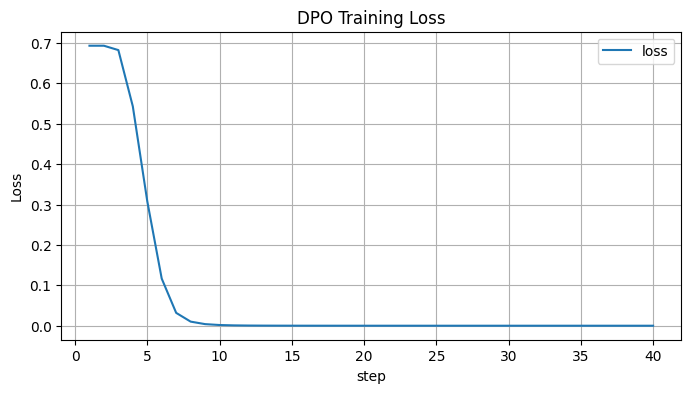

In [16]:
history = pd.DataFrame(trainer.state.log_history)
display(history.tail(20))

loss_history = history.dropna(subset=["loss"]) if "loss" in history.columns else pd.DataFrame()
if not loss_history.empty:
    ax = loss_history.plot(
        x="step",
        y="loss",
        title="DPO Training Loss",
        grid=True,
        figsize=(8, 4),
    )
    ax.set_ylabel("Loss")

## 16. Save the LoRA adapter and tokenizer

In [17]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"Saved DPO LoRA adapter and tokenizer to: {OUTPUT_DIR}")
print("Saved files:")
for file_name in sorted(os.listdir(OUTPUT_DIR)):
    print(" -", file_name)

Saved DPO LoRA adapter and tokenizer to: outputs/qwen2_5_0_5b_dpo_lora
Saved files:
 - README.md
 - adapter_config.json
 - adapter_model.safetensors
 - chat_template.jinja
 - checkpoint-20
 - checkpoint-40
 - tokenizer.json
 - tokenizer_config.json
 - training_args.bin


## 17. Release training memory

In [18]:
del trainer
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Training objects released.")

Training objects released.


## 18. Load the trained PEFT adapter for inference

In [19]:
inference_load_kwargs = {
    "torch_dtype": COMPUTE_DTYPE,
}

if HAS_CUDA:
    inference_load_kwargs["device_map"] = "auto"

if quantization_config is not None:
    inference_load_kwargs["quantization_config"] = quantization_config

model = AutoPeftModelForCausalLM.from_pretrained(
    OUTPUT_DIR,
    **inference_load_kwargs,
)
model.eval()

tokenizer = AutoTokenizer.from_pretrained(
    OUTPUT_DIR,
    trust_remote_code=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "left"

print("DPO adapter loaded successfully.")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


DPO adapter loaded successfully.


## 19. Generate a response

In [20]:
def generate_response(
    prompt: str,
    max_new_tokens: int = 150,
    temperature: float = 0.7,
    top_p: float = 0.9,
) -> str:
    messages = [{"role": "user", "content": prompt}]

    formatted_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        formatted_prompt,
        return_tensors="pt",
    ).to(model.device)

    prompt_token_count = inputs["input_ids"].shape[1]

    generation_kwargs = {
        "max_new_tokens": max_new_tokens,
        "pad_token_id": tokenizer.pad_token_id,
        "eos_token_id": tokenizer.eos_token_id,
    }

    if temperature > 0:
        generation_kwargs.update(
            {
                "do_sample": True,
                "temperature": temperature,
                "top_p": top_p,
            }
        )
    else:
        generation_kwargs["do_sample"] = False

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            **generation_kwargs,
        )

    new_tokens = outputs[0, prompt_token_count:]
    return tokenizer.decode(
        new_tokens,
        skip_special_tokens=True,
    ).strip()


prompt = "Explain overfitting in machine learning in simple words."
response = generate_response(prompt)

print("Prompt:")
print(prompt)
print("\nDPO response:")
print(response)

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Prompt:
Explain overfitting in machine learning in simple words.

DPO response:
Overfitting happens when your model memorizes the data too much and learns patterns that it hasn't seen during training. It's like if you try to draw a picture of a cat using only one drawing paper instead of multiple ones - you'll end up with a picture of a cat, not a real one. Overfitting makes predictions that don't generalize well to new data.


## 20. Test several prompts

In [21]:
test_prompts = [
    "Explain machine learning in simple words.",
    "What is overfitting?",
    "How are classification and regression different?",
    "What does a loss function do?",
]

for current_prompt in test_prompts:
    print("=" * 80)
    print("PROMPT:", current_prompt)
    print("RESPONSE:", generate_response(current_prompt, temperature=0.3))

PROMPT: Explain machine learning in simple words.
RESPONSE: Machine learning is like teaching computers to learn patterns from data and make predictions or decisions based on that learning. It's used to help computers understand the world around us and make sense of it for us!
PROMPT: What is overfitting?
RESPONSE: Overfitting occurs when a model memorizes the training data too closely and performs poorly on new unseen data. It happens because the model has learned the details of the training set too well, but not enough to generalize well to new data. This can happen due to various reasons such as noise in the training data, lack of diversity in the dataset, or insufficiently large training size. Overfitting can lead to poor generalization performance and high prediction errors.
PROMPT: How are classification and regression different?
RESPONSE: Classification predicts categorical labels or categories, while regression predicts continuous numerical values. The main difference is that c

## 21. Download the trained adapter from Colab

In [22]:
import shutil

archive_path = shutil.make_archive(
    base_name="qwen2_5_0_5b_dpo_lora",
    format="zip",
    root_dir=OUTPUT_DIR,
)

print("Created:", archive_path)

# Uncomment in Google Colab:
# from google.colab import files
# files.download(archive_path)

Created: /content/qwen2_5_0_5b_dpo_lora.zip


## Notes for real training

- Four examples only demonstrate that the pipeline runs; they cannot produce a generally aligned model.
- Prefer thousands of high-quality, diverse, correctly labeled preference pairs.
- Keep the prompt distribution close to the model's SFT distribution.
- Evaluate preference accuracy, reward margins, response quality, safety, and held-out generalization.
- A lower DPO loss alone does not prove that the resulting model is better.
- Inspect chosen and rejected responses for label noise, formatting differences, response-length bias, and data leakage.

## Official references

- TRL DPO Trainer: https://huggingface.co/docs/trl/dpo_trainer
- TRL PEFT integration: https://huggingface.co/docs/trl/peft_integration
- PEFT AutoPeftModel: https://huggingface.co/docs/peft/package_reference/auto_class
- Transformers bitsandbytes quantization: https://huggingface.co/docs/transformers/quantization/bitsandbytes